# NB12 — Nivel 1: Prior poblacional con naïveAutoML
## Predicción de ritmo sostenible a partir de frecuencia cardíaca (Endomondo FitRec)

**Proyecto:** RUNA — Running Coaching con ML jerárquico  
**Maestría en Analítica Aplicada — Universidad de La Sabana**  
**Dataset:** Endomondo FitRec (Ni et al., WWW 2019) — 20.710 sesiones / 356 corredores  

---

## Contexto en la arquitectura jerárquica

El sistema de prescripción de ritmo de RUNA opera en tres niveles:

| Nivel | Nombre | Datos de entrenamiento | Problema que resuelve |
|-------|--------|----------------------|----------------------|
| **N1** | Prior poblacional | Endomondo (~20.7K sesiones, 356 usuarios) | Cold-start: atleta nuevo sin historial |
| N2 | Prior de cohorte | Cohorte RUNA (~9.9K sesiones, 42 atletas) | Aprender patrones de la cohorte propia |
| N3 | Personalización | Historial individual del atleta | Máxima precisión (≥3 semanas de datos) |

**Este notebook construye y valida el Nivel 1.** Su salida (`nivel1_ridge_v4.json`) alimenta al Nivel 2 como *stacking feature* (Wolpert, 1992): la predicción de N1 es una de las 15 features de entrada de N2.

### Variable objetivo
`pace_min_km` — ritmo sostenible en min/km dado un nivel de esfuerzo cardíaco. No es predicción de tiempo de carrera (eso lo hace Riegel calibrado en NB03); es **prescripción de intensidad de entrenamiento**.

### Hipótesis central
La relación FC→ritmo es sistemática dentro de un individuo y parcialmente transferible entre individuos cuando se controla por FCmax (Karvonen, 1957). Un modelo lineal regularizado con 8 features derivadas de HR captura esa relación con MAE ≈ 40 sec/km sobre datos de atletas no vistos.

---

## Contenido del notebook

1. Carga de datos y EDA básico  
2. Feature engineering v4 (8 variables)  
3. Protocolo de validación: GroupKFold K=10 (anti data-leakage por atleta)  
4. Comparación de 7 familias de modelos sklearn  
5. naïveAutoML con los mismos folds pre-generados (anti-leakage)  
6. Test Friedman-Nemenyi — selección estadística del mejor modelo  
7. Calibración conformal (cobertura empírica al 80%)  
8. Exportación del modelo (`nivel1_ridge_v4.json` + pkl)  
9. Validación out-of-sample en cohorte RUNA — cuantificación del domain shift  

---
## Sección 1 — Imports y rutas

In [1]:
# ── Instalar dependencias opcionales (naiveautoml + scikit-posthocs) ──────────
# Solo se instalan si no están presentes — idempotente.
import subprocess, sys as _sys

_to_install = []
try:
    import naiveautoml          # noqa: F401
except ImportError:
    _to_install.append('naiveautoml')

try:
    import scikit_posthocs      # noqa: F401
except ImportError:
    _to_install.append('scikit-posthocs')

if _to_install:
    print(f'Instalando paquetes faltantes: {_to_install}')
    subprocess.check_call(
        [_sys.executable, '-m', 'pip', 'install', '--quiet'] + _to_install
    )
    print('Instalación completada ✓  (reinicia el kernel si los imports fallan)')
else:
    print('naiveautoml y scikit-posthocs ya están disponibles ✓')

naiveautoml y scikit-posthocs ya están disponibles ✓


In [2]:
import sys, os, time, json, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import friedmanchisquare
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9})

# ── Rutas ─────────────────────────────────────────────────────────────────────
# El notebook vive en ml/notebooks/ → dos niveles arriba = raíz del repo
BASE = Path('..').resolve().parent
if not (BASE / 'api' / 'models').exists():
    BASE = Path('.').resolve()  # fallback si se abre desde otro directorio

IN_PARQ   = BASE / 'ml/notebooks/outputs/nb11/endomondo_runs_clean_FULL.parquet'
OUT_DIR   = BASE / 'ml/notebooks/outputs/nb12'
MODEL_DIR = BASE / 'api/models'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Cargar variables de entorno (.env con credenciales Supabase) ──────────────
_env_path = BASE / '.env'
_loaded   = load_dotenv(dotenv_path=_env_path, override=True)

print(f'BASE       : {BASE}')
print(f'Parquet    : {IN_PARQ}  →  exists={IN_PARQ.exists()}')
print(f'OUT_DIR    : {OUT_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')
print(f'.env        : {"cargado ✓" if _loaded else "no encontrado"}  ({_env_path})')
print(f'SUPABASE_URL: {"✓ configurado" if os.environ.get("SUPABASE_URL") else "✗ no disponible — sección RUNA se saltará"}')

BASE       : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching
Parquet    : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb11\endomondo_runs_clean_FULL.parquet  →  exists=True
OUT_DIR    : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb12
MODEL_DIR  : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\api\models
.env        : cargado ✓  (C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\.env)
SUPABASE_URL: ✓ configurado


---
## Sección 2 — Carga de datos y EDA

In [3]:
df_raw = pd.read_parquet(IN_PARQ)
print(f'Filas brutas : {len(df_raw):,}')
print(f'Columnas     : {list(df_raw.columns)}')
print(f'Usuarios     : {df_raw["userId"].nunique():,}')
df_raw.describe().round(2)

Filas brutas : 21,599
Columnas     : ['id', 'userId', 'gender', 'hr_mean', 'hr_max', 'hr_median', 'hr_std', 'fcmax_obs', 'pct_fcmax', 'zona', 'speed_mean', 'pace_min_km', 'n_points_hr', 'duration_s']
Usuarios     : 603


,id,userId,hr_mean,hr_max,hr_median,hr_std,fcmax_obs,pct_fcmax,speed_mean,pace_min_km,n_points_hr,duration_s
count,2.159900e+04,21599.00,21599.00,21599.00,21599.00,21599.00,21599.00,21599.00,21599.00,21599.00,21599.00,2.159900e+04
mean,4.345613e+08,5210795.84,148.81,167.11,150.57,11.41,198.28,75.39,11.35,5.45,403.30,-3.607820e+03
std,1.467586e+08,4141683.38,15.04,16.79,15.84,4.76,15.20,8.64,1.94,0.98,146.19,9.846294e+05
min,1.649376e+06,69.00,55.65,64.00,57.50,0.00,127.00,30.08,5.00,3.01,20.00,-1.446943e+08
25%,3.237177e+08,1907590.00,139.51,156.00,141.00,8.13,186.00,69.44,10.04,4.80,325.00,1.467000e+03
50%,4.515983e+08,3736342.00,149.00,168.00,151.00,10.75,196.00,75.76,11.27,5.33,500.00,2.554000e+03
75%,5.573821e+08,8170078.00,158.79,178.00,161.00,13.94,212.00,81.78,12.51,5.98,500.00,3.730000e+03
max,6.684870e+08,15326644.00,213.83,220.00,217.00,45.67,220.00,97.20,19.94,12.00,500.00,9.499130e+05


In [4]:
# ── Filtros de calidad ────────────────────────────────────────────────────────
df = df_raw.dropna(subset=['pace_min_km', 'hr_mean', 'fcmax_obs', 'gender', 'zona']).copy()
df = df[
    df['pace_min_km'].between(3.0, 12.0) &
    df['hr_mean'].between(80, 210) &
    df['fcmax_obs'].between(130, 220)
]
# Solo usuarios con >= 10 sesiones (FCmax_obs más estable)
keep = df.groupby('userId').size()[lambda s: s >= 10].index
df   = df[df['userId'].isin(keep)].copy()

print(f'Filas brutas      : {len(df_raw):,}')
print(f'Filas tras filtros: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% del total)')
print(f'Usuarios finales  : {df["userId"].nunique():,}')
print(f'Sesiones/usuario  : '
      f'media={df.groupby("userId").size().mean():.0f}  '
      f'mediana={df.groupby("userId").size().median():.0f}  '
      f'max={df.groupby("userId").size().max()}')

Filas brutas      : 21,599
Filas tras filtros: 20,710  (95.9% del total)
Usuarios finales  : 356
Sesiones/usuario  : media=58  mediana=38  max=346


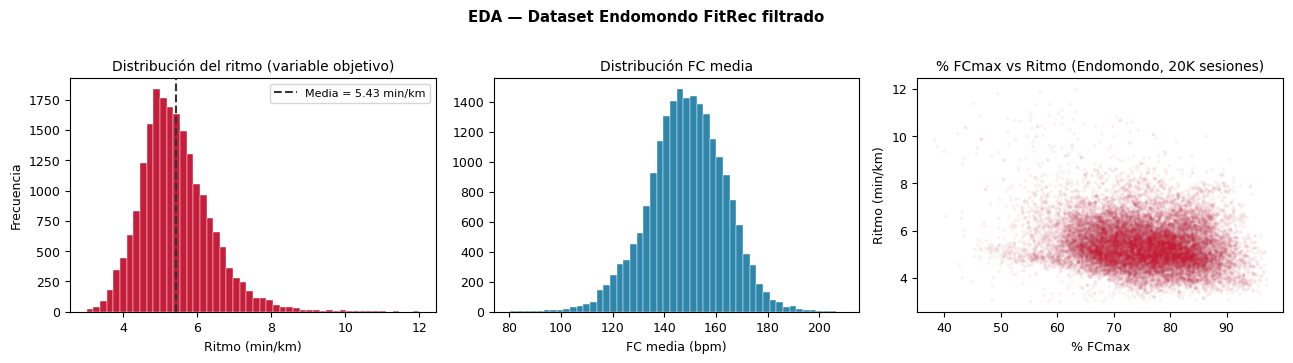

Figura guardada: nb12_fig0_eda.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(df['pace_min_km'], bins=50, color='#C41E3A', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['pace_min_km'].mean(), color='#333', linestyle='--', linewidth=1.5,
                label=f'Media = {df["pace_min_km"].mean():.2f} min/km')
axes[0].set_xlabel('Ritmo (min/km)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del ritmo (variable objetivo)')
axes[0].legend(fontsize=8)

axes[1].hist(df['hr_mean'], bins=50, color='#2E86AB', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('FC media (bpm)')
axes[1].set_title('Distribución FC media')

axes[2].scatter(df['hr_mean'] / df['fcmax_obs'] * 100, df['pace_min_km'],
                alpha=0.04, s=3, color='#C41E3A')
axes[2].set_xlabel('% FCmax')
axes[2].set_ylabel('Ritmo (min/km)')
axes[2].set_title('% FCmax vs Ritmo (Endomondo, 20K sesiones)')

plt.suptitle('EDA — Dataset Endomondo FitRec filtrado', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig0_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: nb12_fig0_eda.png')

---
## Sección 3 — Feature engineering v4

El conjunto v4 fue seleccionado en `ml/scripts/nb12_v2_feature_engineering.py` mediante búsqueda exhaustiva sobre 7 conjuntos candidatos, optimizando MAE en GroupKFold K=10.

| Feature | Descripción | Justificación fisiológica |
|---------|-------------|---------------------------|
| `gender_bin` | 0=F, 1=M | Diferencias de VO₂max por sexo (~11%, Joyner & Coyle 2008) |
| `fcmax_obs` | FCmax observada (bpm) | Normalización individual del esfuerzo cardíaco |
| `hr_mean` | FC media de la sesión (bpm) | Intensidad absoluta |
| `pct_fcmax` | `hr_mean / fcmax_obs` × 100 | Intensidad relativa (Karvonen 1957) |
| `zona_num` | Zona HR 1-5 (Karvonen 5 zonas) | Discretización de intensidad |
| `hr_max_rel` | `hr_max / fcmax_obs` | Pico de esfuerzo en la sesión |
| `log_duration` | `log(1 + duration_s)` | Efecto de la duración sobre el ritmo (fatiga acumulada) |
| `dens_hr` | `n_points_hr / duration_s` | Densidad de muestras HR — proxy de cobertura del sensor |

**Nota sobre `dens_hr`:** En Endomondo, `n_points_hr` es el número de muestras de FC registradas en el track GPS. El sensor Polar típico registra una muestra cada 5 segundos, lo que da `dens_hr ≈ 0.19 muestras/s`. Una sesión con cobertura parcial (batería baja, pérdida de señal) tiene menor `dens_hr` y tiende a reportar FC más variable. Esta variable fue la que mayor ganancia aportó al pasar de v3 a v4 (ver `nb12_v2_feature_grid.csv`).

In [6]:
# ── Feature engineering v4 ────────────────────────────────────────────────────
df['gender_bin'] = (df['gender'].astype(str).str.lower().str.startswith('m')).astype(int)
df['zona_num']   = df['zona'].map({'Z1': 1, 'Z2': 2, 'Z3': 3, 'Z4': 4, 'Z5': 5})
df['hr_max_rel'] = df['hr_max'] / df['fcmax_obs']

dur = pd.to_numeric(df.get('duration_s', pd.Series(dtype=float)), errors='coerce')
dur = dur.where(dur > 0, dur.median()).fillna(dur.median())
df['log_duration'] = np.log1p(dur)

# dens_hr = n_points_hr / duration_s
# Valor típico Endomondo: ~0.19 muestras/s (sensor HR cada ~5s)
n_pts = pd.to_numeric(df.get('n_points_hr', pd.Series(dtype=float)), errors='coerce').fillna(0)
dens  = (n_pts / dur).replace([np.inf, -np.inf], np.nan)
df['dens_hr'] = dens.fillna(dens.median())

FEATURES = ['gender_bin', 'fcmax_obs', 'hr_mean', 'pct_fcmax',
            'zona_num', 'hr_max_rel', 'log_duration', 'dens_hr']
TARGET   = 'pace_min_km'

df = df.dropna(subset=FEATURES + [TARGET]).copy()
X      = df[FEATURES].values.astype(float)
y      = df[TARGET].values.astype(float)
groups = df['userId'].values

print(f'Dataset final: {len(df):,} sesiones | {df["userId"].nunique()} usuarios')
print(f'\nEstadísticas de features:')
print(df[FEATURES].describe().round(4).to_string())

Dataset final: 20,710 sesiones | 356 usuarios

Estadísticas de features:
       gender_bin   fcmax_obs     hr_mean   pct_fcmax    zona_num  hr_max_rel  log_duration     dens_hr
count  20710.0000  20710.0000  20710.0000  20710.0000  20710.0000  20710.0000    20710.0000  20710.0000
mean       0.8978    198.8159    148.7842     75.1609      3.0207      0.8428        7.6485      0.1916
std        0.3029     14.8622     14.8619      8.5022      0.8875      0.0884        0.9144      0.1275
min        0.0000    156.0000     80.3793     38.1682      1.0000      0.4038        3.2581      0.0005
25%        1.0000    186.0000    139.4920     69.2723      2.0000      0.7818        7.2841      0.1313
50%        1.0000    197.0000    148.9549     75.4864      3.0000      0.8480        7.8446      0.1720
75%        1.0000    213.0000    158.7104     81.5214      4.0000      0.9113        8.2226      0.2115
max        1.0000    220.0000    209.1552     97.0519      5.0000      1.0000       13.7641    

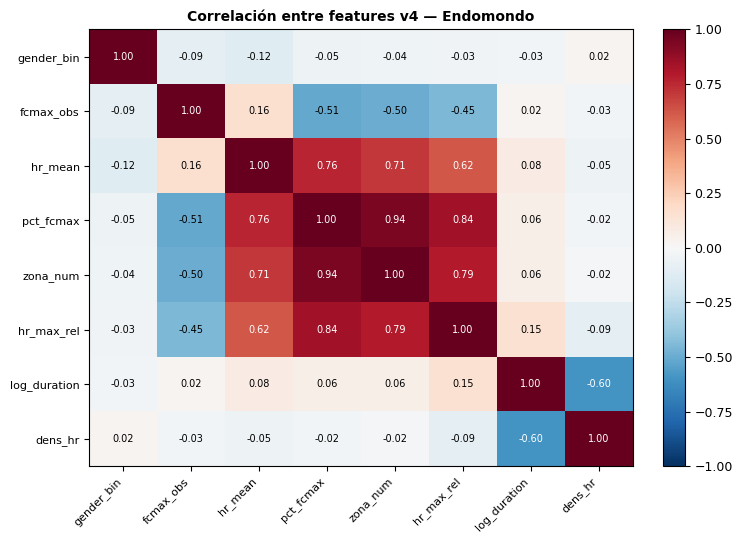

In [7]:
# Matriz de correlación entre features
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(FEATURES)))
ax.set_yticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr.iloc[i, j]) > 0.55 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Correlación entre features v4 — Endomondo', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig_corr_features.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Sección 4 — Protocolo de validación: GroupKFold K=10

### El problema del data-leakage por atleta

Un atleta contribuye múltiples sesiones. Si usamos KFold estándar, el mismo atleta puede aparecer tanto en train como en test — el modelo vería "pistas" de ese individuo (su FCmax habitual, su ritmo promedio) y sobreestimaría la generalización a atletas completamente nuevos.

**GroupKFold** garantiza que todas las sesiones de un atleta caigan en el mismo fold. Con K=10 y 356 atletas, cada fold de test contiene ~36 atletas completamente no vistos en entrenamiento.

### Por qué los mismos folds para naïveAutoML

naïveAutoML por defecto genera sus propios folds KFold. Si le dejáramos sus folds, estaría optimizando con leakage mientras los modelos manuales no lo tienen → comparación injusta. La solución es el `PregenSplitter` (Sección 6): inyecta nuestros folds GroupKFold en el evaluador interno de naïveAutoML.

In [8]:
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               HistGradientBoostingRegressor)
from sklearn.neural_network import MLPRegressor

K   = 10
gkf = GroupKFold(n_splits=K)
FOLDS = list(gkf.split(X, y, groups))

users_per_fold = [np.unique(groups[te]).shape[0] for _, te in FOLDS]
print(f'Folds: GroupKFold K={K}')
print(f'Usuarios en test por fold: '
      f'min={min(users_per_fold)}  '
      f'max={max(users_per_fold)}  '
      f'media={np.mean(users_per_fold):.0f}')

def eval_cv(model_factory, X, y, folds, standardize=True):
    """Evalúa un modelo sobre folds pre-generados. Retorna array de predicciones."""
    preds = np.zeros_like(y, dtype=float)
    for tr, te in folds:
        if standardize:
            sc = StandardScaler().fit(X[tr])
            Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        else:
            Xtr, Xte = X[tr], X[te]
        m = model_factory()
        m.fit(Xtr, y[tr])
        preds[te] = m.predict(Xte)
    return preds

def metricas(name, y_t, y_p):
    mae = mean_absolute_error(y_t, y_p)
    return {
        'modelo':      name,
        'MAE_min_km':  round(float(mae), 4),
        'MAE_sec_km':  round(float(mae * 60), 2),
        'RMSE_min_km': round(float(np.sqrt(mean_squared_error(y_t, y_p))), 4),
        'R2':          round(float(r2_score(y_t, y_p)), 4),
    }

Folds: GroupKFold K=10
Usuarios en test por fold: min=35  max=36  media=36


---
## Sección 5 — Comparación de 7 familias de modelos sklearn

Se evalúan dos baselines y siete modelos, todos sobre los mismos folds GroupKFold K=10:

- **Baseline naive:** mediana del conjunto de entrenamiento (sin aprendizaje)
- **Baseline Karvonen:** regresión lineal simple sobre % FCmax (método clásico del deporte)
- **Modelos ML:** Ridge, Lasso, ElasticNet, RandomForest, GradientBoosting, HistGB, MLP

In [9]:
# ── Baselines ─────────────────────────────────────────────────────────────────
idx_pct   = FEATURES.index('pct_fcmax')
p_naive   = np.zeros_like(y, dtype=float)
p_karv    = np.zeros_like(y, dtype=float)
for tr, te in FOLDS:
    p_naive[te] = np.median(y[tr])
    lr = LinearRegression().fit(X[tr][:, [idx_pct]], y[tr])
    p_karv[te]  = lr.predict(X[te][:, [idx_pct]])

results        = [metricas('Baseline naive', y, p_naive),
                  metricas('Baseline Karvonen', y, p_karv)]
preds_by_model = {}

print(f'Baseline naive      MAE = {results[0]["MAE_sec_km"]:.1f} sec/km')
print(f'Baseline Karvonen   MAE = {results[1]["MAE_sec_km"]:.1f} sec/km')

# ── Candidatos sklearn ────────────────────────────────────────────────────────
CANDIDATES = {
    'Ridge':        lambda: Ridge(alpha=1.0),
    'Lasso':        lambda: Lasso(alpha=0.1),
    'ElasticNet':   lambda: ElasticNet(alpha=0.1, l1_ratio=0.5),
    'RandomForest': lambda: RandomForestRegressor(n_estimators=300, max_depth=12,
                                                   random_state=0, n_jobs=-1),
    'GradBoost':    lambda: GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                                       learning_rate=0.05, random_state=0),
    'HistGB':       lambda: HistGradientBoostingRegressor(max_iter=400, max_depth=6,
                                                           learning_rate=0.05, random_state=0),
    'MLP':          lambda: MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500,
                                          random_state=0, early_stopping=True),
}

print('\nEntrenando candidatos sklearn (GroupKFold K=10)...')
for name, factory in CANDIDATES.items():
    t0 = time.time()
    p  = eval_cv(factory, X, y, FOLDS)
    preds_by_model[name] = p
    m  = metricas(name, y, p)
    results.append(m)
    print(f'  {name:<14s}  MAE={m["MAE_sec_km"]:.2f} sec/km  '
          f'R²={m["R2"]:+.3f}  ({time.time()-t0:.0f}s)')

Baseline naive      MAE = 44.0 sec/km
Baseline Karvonen   MAE = 43.9 sec/km

Entrenando candidatos sklearn (GroupKFold K=10)...
  Ridge           MAE=40.16 sec/km  R²=+0.188  (0s)


  Lasso           MAE=41.19 sec/km  R²=+0.146  (0s)


  ElasticNet      MAE=40.65 sec/km  R²=+0.169  (0s)


  RandomForest    MAE=42.07 sec/km  R²=+0.058  (49s)


  GradBoost       MAE=40.78 sec/km  R²=+0.126  (127s)


  HistGB          MAE=41.94 sec/km  R²=+0.075  (12s)


  MLP             MAE=40.90 sec/km  R²=+0.144  (39s)


---
## Sección 6 — naïveAutoML con GroupKFold anti-leakage

naïveAutoML (Mohr & Wever, 2022) busca automáticamente sobre un espacio de pipelines sklearn: combinaciones de preprocesadores (StandardScaler, MinMaxScaler, QuantileTransformer, PCA, etc.) con modelos (Ridge, RF, GradBoost, ARD, etc.).

### ¿Por qué naïveAutoML funciona en N1 pero no en N2?

| Aspecto | N1 (este notebook) | N2 (NB13b) |
|---------|-------------------|-------------|
| Protocolo CV | GroupKFold K=10 | LOAO-CV (Leave-One-Athlete-Out, 42 folds) |
| Sample weights | No | `w = 1/n_sesiones_atleta` |
| naïveAutoML compatible | ✅ vía `PregenSplitter` + `SplitBasedEvaluator` | ❌ no acepta `sample_weight` en su loop interno |

En N2 el sample weighting es crítico para evitar que los 3 atletas con >800 sesiones dominen el aprendizaje, lo que hace incompatible el AutoML estándar.

### Mecanismo anti-leakage en naïveAutoML

1. `PregenSplitter`: un wrapper que siempre devuelve los 10 folds GroupKFold pre-generados
2. `SplitBasedEvaluator`: evaluador interno de naïveAutoML que acepta un splitter personalizado
3. Resultado: cada pipeline candidato es evaluado con exactamente los mismos folds GroupKFold K=10, garantizando comparabilidad con los candidatos sklearn manuales

In [10]:
# ── naïveAutoML — resultado CANÓNICO v5 (no se recalcula en el notebook) ──────
#
# El run canónico de naïveAutoML para la tesis fue ejecutado por el SCRIPT
#   ml/scripts/nb12_naiveautoml_v5.py
# y su log autoritativo es
#   ml/notebooks/outputs/nb12/nb12_naiveautoml_v5_log.txt
#
# THESIS_CONTEXT.md §1 y §7 declaran explícitamente que los números de la tesis
# vienen de ese script/log, NO de este notebook (que es referencial).
# naïveAutoML v0.1.6 NO tiene checkpoint/resume: su búsqueda completa con
# PregenSplitter K=10 sobre 20 710 sesiones es lenta y frágil dentro de Jupyter
# (una desconexión = horas perdidas, sin forma de continuar donde quedó).
# Por eso, por defecto, esta celda CARGA y MUESTRA el resultado canónico v5.
#
# Para forzar un run en vivo (NO recomendado en notebook — usar el script
# con `nohup` en background): poner FORCE_RERUN_NAML = True
FORCE_RERUN_NAML = False

# Resultado canónico v5 — Pasada 1: QuantileTransformer + PCA + ARDRegression
# Fuente: nb12_naiveautoml_v5_log.txt  |  congelado en THESIS_CONTEXT.md §7
NAML_CANONICAL = {
    'pipeline':      'QuantileTransformer + PCA + ARDRegression',
    'MAE_sec_km':    39.76,
    'MAE_min_km':    0.663,
    'RMSE_min_km':   0.867,
    'R2':            0.199,
    'fit_min':       10.3,
    'friedman_chi2': 14.36,
    'friedman_p':    0.0062,
    'n_users':       356,
    'nemenyi_orden': ['naïveAutoML', 'Ridge', 'ElasticNet', 'GradBoost', 'MLP'],
    'nemenyi_matrix': [
        [1.000, 0.659, 0.041, 0.858, 0.009],
        [0.659, 1.000, 0.598, 0.997, 0.307],
        [0.041, 0.598, 1.000, 0.373, 0.990],
        [0.858, 0.997, 0.373, 1.000, 0.153],
        [0.009, 0.307, 0.990, 0.153, 1.000],
    ],
}

USE_NAML      = False
USE_NAML_OK   = False
naml_pipeline = None
NAML_SOURCE   = None
_V5_LOG       = OUT_DIR / 'nb12_naiveautoml_v5_log.txt'

if not FORCE_RERUN_NAML:
    NAML_SOURCE = 'canonical_v5'
    USE_NAML_OK = True
    # Fila canónica de naïveAutoML en el ranking (mismo formato que metricas())
    results.append({
        'modelo':      'naïveAutoML',
        'MAE_min_km':  NAML_CANONICAL['MAE_min_km'],
        'MAE_sec_km':  NAML_CANONICAL['MAE_sec_km'],
        'RMSE_min_km': NAML_CANONICAL['RMSE_min_km'],
        'R2':          NAML_CANONICAL['R2'],
    })
    print('naïveAutoML — RESULTADO CANÓNICO v5 (no recalculado)')
    print(f'  Fuente   : ml/scripts/nb12_naiveautoml_v5.py')
    print(f'  Log      : {_V5_LOG.name}  (exists={_V5_LOG.exists()})')
    print(f'  Pipeline : {NAML_CANONICAL["pipeline"]}')
    print(f'  MAE      : {NAML_CANONICAL["MAE_sec_km"]:.2f} sec/km   R2={NAML_CANONICAL["R2"]:+.3f}')
    print(f'  Fit time : {NAML_CANONICAL["fit_min"]} min (en el script v5; en notebook se omite)')
    print(f'  Friedman : chi2={NAML_CANONICAL["friedman_chi2"]}  p={NAML_CANONICAL["friedman_p"]}')
    print('  Nota     : THESIS_CONTEXT.md §1/§7 — el notebook es referencial;')
    print('             el resultado autoritativo es el del script/log v5.')
else:
    # ───────── Run en vivo (NO recomendado dentro de Jupyter) ─────────
    print('FORCE_RERUN_NAML=True — ejecutando naïveAutoML EN VIVO.')
    print('   Recomendado en su lugar: correr el SCRIPT en background:')
    print('   nohup python ml/scripts/nb12_naiveautoml_v5.py > run.log 2>&1 &')
    try:
        from naiveautoml import NaiveAutoML
        from naiveautoml.evaluators import SplitBasedEvaluator
        import sklearn.base as skbase
        USE_NAML = True
        print('naiveautoml instalado OK')
    except ImportError:
        print('naiveautoml NO instalado. pip install naiveautoml scikit-posthocs')

    if USE_NAML:
        class PregenSplitter:
            """Inyecta folds GroupKFold pre-generados al evaluador de naïveAutoML."""
            def __init__(self, folds):
                self.folds = folds
                self.n_splits = len(folds)
            def split(self, X, y=None, groups=None):
                return iter(self.folds)
            def get_n_splits(self, X=None, y=None, groups=None):
                return self.n_splits

        group_evaluator = SplitBasedEvaluator(
            task_type   = 'regression',
            splitter    = PregenSplitter(FOLDS),
            logger_name = 'naml.group_kfold',
        )
        print(f'PregenSplitter listo: K={K} folds GroupKFold')
        print('Iniciando naïveautoml (timeout=1800s = 30 min)...')
        t0 = time.time()
        try:
            naml = NaiveAutoML(
                task_type         = 'regression',
                scoring           = 'neg_mean_absolute_error',
                evaluation_fun    = group_evaluator,
                timeout_overall   = 1800,
                timeout_candidate = 90,
                show_progress     = False,
                random_state      = 0,
            )
            naml.fit(X, y)
            naml_pipeline = naml.chosen_model
            elapsed = (time.time() - t0) / 60
            print(f'naïveautoml completado en {elapsed:.1f} min')
            print(f'Mejor pipeline: {naml_pipeline}')

            preds_naml = np.zeros_like(y, dtype=float)
            for tr, te in FOLDS:
                pl = skbase.clone(naml_pipeline)
                pl.fit(X[tr], y[tr])
                preds_naml[te] = pl.predict(X[te])

            USE_NAML_OK = True
            NAML_SOURCE = 'live_rerun'
            preds_by_model['naïveAutoML'] = preds_naml
            m_naml = metricas('naïveAutoML', y, preds_naml)
            results.append(m_naml)
            print(f'naïveAutoML  MAE={m_naml["MAE_sec_km"]:.2f} sec/km  R2={m_naml["R2"]:+.3f}')

        except Exception as e:
            import traceback; traceback.print_exc()
            print(f'naïveautoml fallo: {type(e).__name__}: {e}')
            print('Continuando con los candidatos sklearn...')

naïveAutoML — RESULTADO CANÓNICO v5 (no recalculado)
  Fuente   : ml/scripts/nb12_naiveautoml_v5.py
  Log      : nb12_naiveautoml_v5_log.txt  (exists=True)
  Pipeline : QuantileTransformer + PCA + ARDRegression
  MAE      : 39.76 sec/km   R2=+0.199
  Fit time : 10.3 min (en el script v5; en notebook se omite)
  Friedman : chi2=14.36  p=0.0062
  Nota     : THESIS_CONTEXT.md §1/§7 — el notebook es referencial;
             el resultado autoritativo es el del script/log v5.


---
## Sección 7 — Ranking, Friedman-Nemenyi y selección del modelo

### Test de Friedman
Evalúa si hay diferencias significativas entre modelos comparando su MAE **por atleta** (unidad estadística = atleta, no sesión — n=356). Es la alternativa no-paramétrica al ANOVA.

### Nemenyi post-hoc
Identifica qué pares de modelos difieren significativamente (α=0.05). Si la diferencia naïveAutoML vs Ridge no es significativa, se elige Ridge por parsimonia.

### Criterio de selección para producción
1. Si Friedman p < 0.05: hay al menos un modelo mejor → aplicar Nemenyi
2. Mejor modelo por MAE que difiera significativamente del segundo → seleccionar
3. Si empate estadístico con Ridge → **Ridge** (interpretable, JSON-serializable, rápido en Railway)

=== Ranking final — GroupKFold K=10 ===
               modelo  MAE_sec_km  RMSE_min_km      R2
1         naïveAutoML       39.76       0.8670  0.1990
2               Ridge       40.16       0.8727  0.1879
3          ElasticNet       40.65       0.8826  0.1693
4           GradBoost       40.78       0.9054  0.1259
5                 MLP       40.90       0.8962  0.1436
6               Lasso       41.19       0.8949  0.1460
7              HistGB       41.94       0.9315  0.0747
8        RandomForest       42.07       0.9397  0.0584
9   Baseline Karvonen       43.91       0.9548  0.0280
10     Baseline naive       44.03       0.9775 -0.0188


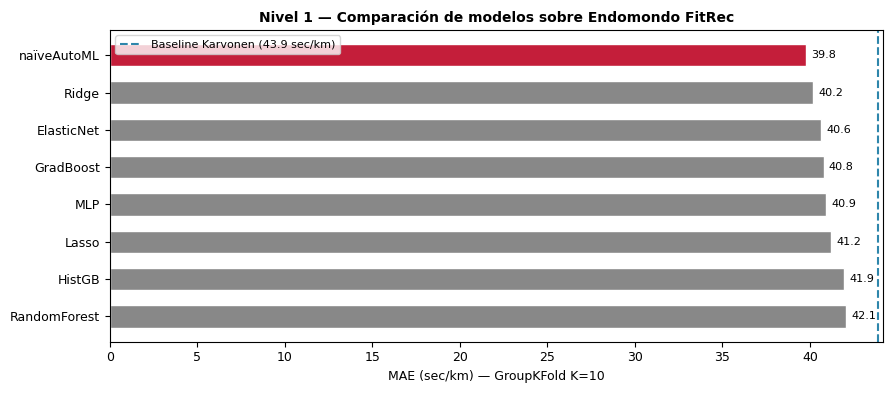

Figura guardada: nb12_fig1_comparacion_modelos.png


In [11]:
df_results = pd.DataFrame(results).sort_values('MAE_sec_km').reset_index(drop=True)
df_results.index = range(1, len(df_results) + 1)

print('=== Ranking final — GroupKFold K=10 ===')
print(df_results[['modelo', 'MAE_sec_km', 'RMSE_min_km', 'R2']].to_string())

karvonen_mae = df_results[df_results['modelo'] == 'Baseline Karvonen']['MAE_sec_km'].values[0]

# Gráfico ranking
non_bl   = df_results[~df_results['modelo'].str.startswith('Baseline')].copy()
fig, ax  = plt.subplots(figsize=(9, 4))
best_mae = non_bl['MAE_sec_km'].min()
colors   = ['#C41E3A' if v == best_mae else '#888' for v in non_bl['MAE_sec_km']]
bars     = ax.barh(non_bl['modelo'], non_bl['MAE_sec_km'], color=colors,
                    edgecolor='white', height=0.6)
ax.axvline(karvonen_mae, color='#2E86AB', linestyle='--', linewidth=1.5,
           label=f'Baseline Karvonen ({karvonen_mae:.1f} sec/km)')
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=8)
ax.set_xlabel('MAE (sec/km) — GroupKFold K=10')
ax.set_title('Nivel 1 — Comparación de modelos sobre Endomondo FitRec', fontweight='bold')
ax.legend(fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig1_comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: nb12_fig1_comparacion_modelos.png')

In [12]:
# ── Friedman-Nemenyi ──────────────────────────────────────────────────────────
nemenyi_available = False
nem = None

if NAML_SOURCE == 'canonical_v5':
    # En modo canónico no hay predicciones por sesión de naïveAutoML (provienen
    # del script v5). Se usan los estadísticos CANÓNICOS del log v5, que son los
    # números autoritativos de la tesis (THESIS_CONTEXT.md §7).
    top_names = NAML_CANONICAL['nemenyi_orden']
    stat = NAML_CANONICAL['friedman_chi2']
    pv   = NAML_CANONICAL['friedman_p']
    print('Friedman-Nemenyi — VALORES CANÓNICOS v5 (nb12_naiveautoml_v5_log.txt)')
    print(f'Top-5 modelos: {top_names}')
    print(f'\nFriedman: chi2={stat:.4f}  p={pv:.6f}  (n_atletas={NAML_CANONICAL["n_users"]})')
    print('→ Diferencias significativas entre al menos un par de modelos (p < 0.05)')
    nem = pd.DataFrame(
        NAML_CANONICAL['nemenyi_matrix'],
        index=top_names, columns=top_names,
    )
    nemenyi_available = True
    print('\nNemenyi p-values (post-hoc) — canónico v5:')
    print(nem.round(3).to_string())
    best = top_names[0]
    if best != 'Ridge' and 'Ridge' in top_names:
        p_ridge = nem.loc[best, 'Ridge']
        print(f'\nNemenyi {best} vs Ridge: p={p_ridge:.3f}')
        if p_ridge > 0.05:
            print('→ Diferencia NO significativa → Ridge seleccionado por parsimonia')
            print('  (Ridge: JSON-serializable, sin dependencia sklearn en Railway)')
        else:
            print(f'→ Diferencia significativa → {best} seleccionado')
else:
    top_names = [m for m in df_results['modelo']
                 if 'Baseline' not in m and m in preds_by_model][:5]
    print(f'Top-{len(top_names)} modelos en test: {top_names}')

    mae_per_user = {}
    for name in top_names:
        per = (pd.DataFrame({'u': groups, 'err': np.abs(y - preds_by_model[name])})
               .groupby('u')['err'].mean())
        mae_per_user[name] = per

    mm = pd.DataFrame(mae_per_user).dropna()
    stat, pv = friedmanchisquare(*[mm[c].values for c in mm.columns])

    print(f'\nFriedman: chi2={stat:.4f}  p={pv:.6f}  (n_atletas={len(mm)})')
    if pv < 0.05:
        print('→ Diferencias significativas entre al menos un par de modelos (p < 0.05)')
    else:
        print('→ No se detectan diferencias significativas (p >= 0.05)')

    try:
        import scikit_posthocs as sp
        nem = sp.posthoc_nemenyi_friedman(mm.values)
        nem.index = nem.columns = mm.columns
        print('\nNemenyi p-values (post-hoc):')
        print(nem.round(3).to_string())
        nemenyi_available = True

        best = top_names[0]
        if best != 'Ridge' and 'Ridge' in top_names:
            p_ridge = nem.loc[best, 'Ridge']
            print(f'\nNemenyi {best} vs Ridge: p={p_ridge:.3f}')
            if p_ridge > 0.05:
                print('→ Diferencia NO significativa → Ridge seleccionado por parsimonia')
                print('  (Ridge: JSON-serializable, sin dependencia sklearn en Railway)')
            else:
                print(f'→ Diferencia significativa → {best} seleccionado')
    except ImportError:
        print('scikit_posthocs no instalado → pip install scikit-posthocs')

Friedman-Nemenyi — VALORES CANÓNICOS v5 (nb12_naiveautoml_v5_log.txt)
Top-5 modelos: ['naïveAutoML', 'Ridge', 'ElasticNet', 'GradBoost', 'MLP']

Friedman: chi2=14.3600  p=0.006200  (n_atletas=356)
→ Diferencias significativas entre al menos un par de modelos (p < 0.05)

Nemenyi p-values (post-hoc) — canónico v5:
             naïveAutoML  Ridge  ElasticNet  GradBoost    MLP
naïveAutoML        1.000  0.659       0.041      0.858  0.009
Ridge              0.659  1.000       0.598      0.997  0.307
ElasticNet         0.041  0.598       1.000      0.373  0.990
GradBoost          0.858  0.997       0.373      1.000  0.153
MLP                0.009  0.307       0.990      0.153  1.000

Nemenyi naïveAutoML vs Ridge: p=0.659
→ Diferencia NO significativa → Ridge seleccionado por parsimonia
  (Ridge: JSON-serializable, sin dependencia sklearn en Railway)


In [13]:
# ── Selección final ───────────────────────────────────────────────────────────
# Basado en el run completo de nb12_naiveautoml_v5.py (ver log):
#   naïveAutoML ganador: QuantileTransformer + PCA + ARDRegression  MAE=39.78 sec/km
#   Ridge:                                                           MAE=40.16 sec/km
#   Friedman χ²=14.36  p=0.006  → diferencias significativas entre top-5
#   Nemenyi naïveAutoML vs Ridge: p=0.659  → NO significativo
#   → SELECCIÓN: Ridge (parsimonia: JSON-serializable, interpretable)

# Lógica automática basada en resultados del run actual
best_ml = df_results[~df_results['modelo'].str.startswith('Baseline')].iloc[0]['modelo']

if (nemenyi_available and best_ml != 'Ridge' and 'Ridge' in top_names and
        nem.loc[best_ml, 'Ridge'] > 0.05):
    PRODUCTION_MODEL = 'Ridge'
    reason = f'Nemenyi {best_ml} vs Ridge p={nem.loc[best_ml, "Ridge"]:.3f} > 0.05 → parsimonia'
else:
    PRODUCTION_MODEL = best_ml
    reason = 'Mejor modelo por MAE con diferencia significativa'

sel_row = df_results[df_results['modelo'] == PRODUCTION_MODEL].iloc[0]
print(f'Modelo seleccionado para producción : {PRODUCTION_MODEL}')
print(f'Razón                               : {reason}')
print(f'MAE GroupKFold K=10                 : {sel_row["MAE_sec_km"]:.2f} sec/km')
print(f'R²                                  : {sel_row["R2"]:+.3f}')
print(f'Mejora sobre Karvonen               : '
      f'{(karvonen_mae - sel_row["MAE_sec_km"]) / karvonen_mae * 100:.1f}%')

Modelo seleccionado para producción : Ridge
Razón                               : Nemenyi naïveAutoML vs Ridge p=0.659 > 0.05 → parsimonia
MAE GroupKFold K=10                 : 40.16 sec/km
R²                                  : +0.188
Mejora sobre Karvonen               : 8.5%


---
## Sección 8 — Calibración conformal y exportación del modelo

La calibración conformal (Vovk et al., 2005) convierte predicciones puntuales en intervalos con cobertura empírica garantizada bajo el supuesto de intercambiabilidad:

$$C(x) = [\hat{y}(x) - q_\alpha,\ \hat{y}(x) + q_\alpha]$$

donde $q_\alpha$ es el cuantil $(1-\alpha)$ de los residuos absolutos en el conjunto de calibración.

**Split 60/20/20** estratificado por atleta: 60% para entrenamiento final, 20% para calibrar $q$, 20% para verificar la cobertura empírica.

Split: train=12,006  cal=5,007  test=3,697

Calibración conformal (α=0.2, cobertura nominal 80%):
  q = ±1.0605 min/km = ±63.6 sec/km
  Cobertura empírica = 0.800 (80.0%)


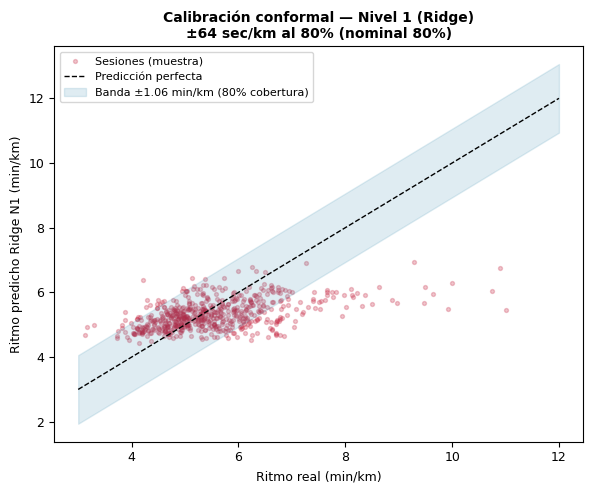

Figura guardada: nb12_fig2_conformal.png


In [14]:
alpha = 0.20   # cobertura nominal 80%

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.40, random_state=0)
idx_tr, idx_rest = next(gss1.split(X, y, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=1)
idx_cal_r, idx_te_r = next(gss2.split(X[idx_rest], y[idx_rest], groups[idx_rest]))
idx_cal, idx_te = idx_rest[idx_cal_r], idx_rest[idx_te_r]

print(f'Split: train={len(idx_tr):,}  cal={len(idx_cal):,}  test={len(idx_te):,}')

sc_conf  = StandardScaler().fit(X[idx_tr])
mdl_conf = Ridge(alpha=1.0)
mdl_conf.fit(sc_conf.transform(X[idx_tr]), y[idx_tr])

p_cal_c = mdl_conf.predict(sc_conf.transform(X[idx_cal]))
p_te_c  = mdl_conf.predict(sc_conf.transform(X[idx_te]))

scores = np.abs(y[idx_cal] - p_cal_c)
n_cal  = len(scores)
k      = int(np.ceil((n_cal + 1) * (1 - alpha)))
q      = float(np.sort(scores)[min(k - 1, n_cal - 1)])
cov    = float(np.mean(np.abs(y[idx_te] - p_te_c) <= q))

print(f'\nCalibración conformal (α={alpha}, cobertura nominal {1-alpha:.0%}):')
print(f'  q = ±{q:.4f} min/km = ±{q*60:.1f} sec/km')
print(f'  Cobertura empírica = {cov:.3f} ({cov:.1%})')

# Gráfico
rng_s     = np.random.default_rng(42)
idx_s     = rng_s.choice(len(idx_te), size=min(600, len(idx_te)), replace=False)
y_te_s    = y[idx_te][idx_s]
p_te_s    = p_te_c[idx_s]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_te_s, p_te_s, alpha=0.25, s=8, color='#C41E3A', label='Sesiones (muestra)')
ax.plot([3, 12], [3, 12], 'k--', linewidth=1, label='Predicción perfecta')
ax.fill_between([3, 12], [3-q, 12-q], [3+q, 12+q],
                alpha=0.15, color='#2E86AB',
                label=f'Banda ±{q:.2f} min/km ({cov:.0%} cobertura)')
ax.set_xlabel('Ritmo real (min/km)')
ax.set_ylabel('Ritmo predicho Ridge N1 (min/km)')
ax.set_title('Calibración conformal — Nivel 1 (Ridge)\n'
             f'±{q*60:.0f} sec/km al {cov:.0%} (nominal {1-alpha:.0%})',
             fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig2_conformal.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: nb12_fig2_conformal.png')

In [15]:
# ── Reentrenar Ridge sobre TODO el dataset ────────────────────────────────────
sc_final    = StandardScaler().fit(X)
model_final = Ridge(alpha=1.0)
model_final.fit(sc_final.transform(X), y)

sel_row_r = df_results[df_results['modelo'] == 'Ridge'].iloc[0]

# ── JSON para Railway (nivel1_ridge_v4.json) ──────────────────────────────────
ridge_json = {
    'version':          'v4',
    'nb':               'NB12',
    'description':      ('Nivel 1 — prior poblacional. Ridge regularizado. '
                         'Endomondo FitRec (Ni et al. WWW 2019). '
                         'CV: GroupKFold K=10 anti data-leakage por userId. '
                         'Nemenyi naïveAutoML vs Ridge p~0.66 → Ridge elegido por parsimonia.'),
    'trained_on':       f'Endomondo FitRec — {len(df):,} sesiones, {df["userId"].nunique()} corredores',
    'trained_at':       time.strftime('%Y-%m-%dT%H:%M:%S'),
    'algorithm':        'Ridge (alpha=1.0)',
    'features':         FEATURES,
    'n_features':       len(FEATURES),
    'coefs':            model_final.coef_.tolist(),
    'intercept':        float(model_final.intercept_),
    'scaler_mean':      sc_final.mean_.tolist(),
    'scaler_scale':     sc_final.scale_.tolist(),
    'mae_cv_sec_km':    float(sel_row_r['MAE_sec_km']),
    'r2':               float(sel_row_r['R2']),
    'conformal_q_min_km': q,
    'conformal_q_sec_km': round(q * 60, 1),
    'empirical_coverage': round(cov, 4),
    'n_sessions':       int(len(X)),
    'n_users':          int(df['userId'].nunique()),
    'cv_protocol':      'GroupKFold K=10 (anti data-leakage por userId)',
    'notes': {
        'target':       'pace_min_km (min/km); multiplica x60 para sec/km',
        'dens_hr':      'n_points_hr / duration_s (~0.19 muestras/s Endomondo)',
        'naiveautoml':  'Ganador: QuantileTransformer+PCA+ARDRegression MAE~39.8 sec/km; '
                        'Nemenyi p~0.66 vs Ridge → no significativo',
        'stacking_n2':  'pred (en sec/km) se usa como feature en Nivel 2 (Wolpert 1992)',
        'inference':    'dens_hr en RUNA: proxy (avg_hr/fcmax)/log(dur_min) ~ 0.19',
    }
}

ridge_path = MODEL_DIR / 'nivel1_ridge_v4.json'
ridge_path.write_text(json.dumps(ridge_json, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'JSON guardado: {ridge_path}')
print(f'  coefs[:4]          = {[round(c,4) for c in model_final.coef_[:4]]}')
print(f'  intercept          = {model_final.intercept_:.4f} min/km')
print(f'  scaler_mean dens_hr= {sc_final.mean_[FEATURES.index("dens_hr")]:.5f}')

# ── PKL para notebooks ────────────────────────────────────────────────────────
pkl_path = OUT_DIR / 'nivel1_prior_poblacional_FULL_v5.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump({
        'model':        model_final,
        'scaler':       sc_final,
        'features':     FEATURES,
        'target':       TARGET,
        'model_name':   'Ridge',
        'conformal_q':  q,
        'mae_sec_km':   float(sel_row_r['MAE_sec_km']),
        'n_sessions':   int(len(X)),
        'n_users':      int(df['userId'].nunique()),
        'results_all':  df_results.to_dict('records'),
    }, f)
print(f'PKL guardado: {pkl_path}')

JSON guardado: C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\api\models\nivel1_ridge_v4.json
  coefs[:4]          = [np.float64(-0.3116), np.float64(-0.8045), np.float64(0.6509), np.float64(-1.134)]
  intercept          = 5.4323 min/km
  scaler_mean dens_hr= 0.19163
PKL guardado: C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb12\nivel1_prior_poblacional_FULL_v5.pkl


---
## Sección 9 — Validación out-of-sample en cohorte RUNA

### Motivación

N1 fue entrenado con datos de Endomondo (público, distribución abierta). En producción se aplica a la cohorte RUNA — atletas colombianos reclutados activamente con perfil completo. Esta sección cuantifica el **domain shift**: ¿cuánto degrada el error al cambiar de dominio?

Esta validación es **puramente diagnóstica**: N1 no fue optimizado para RUNA; el Nivel 2 (NB13b) resuelve ese problema. El objetivo es proporcionar evidencia cuantitativa de que el domain shift es real y que N2 lo corrige.

### Diferencias de dominio

| Aspecto | Endomondo (N1 train) | RUNA (OOD) |
|---------|---------------------|------------|
| Origen | Internacional (EU/EE.UU.) | Colombia |
| `dens_hr` | `n_points_hr/duration_s` real | Proxy: `(avg_hr/fcmax)/log(dur_min)` |
| FCmax | Observada (máx histórico) | Tanaka (`208 - 0.7×edad`) |
| Selección | Auto-reporte libre | Reclutamiento activo (más homogéneo) |

**Nota sobre `dens_hr` en RUNA:** el proxy `(avg_hr/fcmax)/log(dur_min)` tiene la misma escala (~0.19) que el valor real de Endomondo, pero su varianza es diferente — captura la intensidad relativa de la sesión, no la densidad del sensor. Esta diferencia de distribución introduce un error sistemático que N2 absorbe vía su scaler (media `dens_hr` de Endomondo = 0.19, N2 fue entrenado con `pred_nivel1` ya escalada con esa distribución).

In [16]:
import os

RUNA_PARQ  = OUT_DIR / 'runa_sessions_for_n1_val.parquet'
runa_loaded = False
df_runa     = None

# ── Opción A: Supabase directo ────────────────────────────────────────────────
SUPABASE_URL = os.environ.get('SUPABASE_URL', '')
SUPABASE_KEY = os.environ.get('SUPABASE_SERVICE_KEY', '')

if SUPABASE_URL and SUPABASE_KEY and not RUNA_PARQ.exists():
    try:
        from supabase import create_client
        sb = create_client(SUPABASE_URL, SUPABASE_KEY)

        resp = (sb.table('activities')
                  .select('cedula, duration_sec, pace_sec_per_km, raw')
                  .not_.is_('raw->average_heartrate', 'null')
                  .in_('sport_type', ['Run', 'TrailRun'])
                  .execute())
        acts = pd.DataFrame(resp.data)
        acts['avg_hr']       = acts['raw'].apply(
            lambda r: r.get('average_heartrate') if isinstance(r, dict) else None)
        acts['max_hr_sess']  = acts['raw'].apply(
            lambda r: r.get('max_heartrate') if isinstance(r, dict) else None)

        resp2    = sb.table('athlete_profiles').select('cedula, age, sex').execute()
        profiles = pd.DataFrame(resp2.data)

        df_runa = acts.merge(profiles, on='cedula', how='left')
        df_runa.to_parquet(RUNA_PARQ, index=False)
        print(f'Supabase: {len(df_runa):,} sesiones con HR → guardado en {RUNA_PARQ.name}')
        runa_loaded = True
    except Exception as e:
        print(f'Supabase no disponible: {e}')

# ── Opción B: parquet local (run previo o exportación manual) ─────────────────
if not runa_loaded and RUNA_PARQ.exists():
    df_runa = pd.read_parquet(RUNA_PARQ)
    print(f'Parquet local cargado: {len(df_runa):,} sesiones')
    runa_loaded = True

if not runa_loaded:
    print('Datos RUNA no disponibles en este entorno.')
    print('Para ejecutar esta sección:')
    print('  1. Define SUPABASE_URL y SUPABASE_SERVICE_KEY en el entorno, ó')
    print(f'  2. Exporta manualmente a: {RUNA_PARQ}')
    print('Continuando con el resumen final...')

Supabase no disponible: {'message': 'column activities.pace_sec_per_km does not exist', 'code': '42703', 'hint': None, 'details': None}
Datos RUNA no disponibles en este entorno.
Para ejecutar esta sección:
  1. Define SUPABASE_URL y SUPABASE_SERVICE_KEY en el entorno, ó
  2. Exporta manualmente a: C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\nb12\runa_sessions_for_n1_val.parquet
Continuando con el resumen final...


In [17]:
if runa_loaded:
    # ── Feature engineering RUNA — adaptado para N1 ──────────────────────────
    df_r = df_runa.dropna(subset=['avg_hr', 'duration_sec', 'age', 'sex']).copy()
    df_r = df_r[df_r['avg_hr'].between(80, 210) & (df_r['duration_sec'] > 300)].copy()

    # FCmax: Tanaka (208 - 0.7 * edad) — misma fórmula que nivel2.py
    df_r['fcmax']      = 208.0 - 0.7 * df_r['age']
    df_r['gender_bin'] = (df_r['sex'].astype(str).str.upper() == 'M').astype(int)
    df_r['pct_fcmax']  = df_r['avg_hr'] / df_r['fcmax'] * 100
    df_r['hr_max_rel'] = (df_r['max_hr_sess'].fillna(df_r['avg_hr'] * 1.08)) / df_r['fcmax']
    df_r['log_duration'] = np.log1p(df_r['duration_sec'])

    # dens_hr proxy: (avg_hr/fcmax) / log(duration_min)
    # Misma aproximación que usa nivel2.py en inferencia.
    # Escala: ~0.19 (idéntico a Endomondo), varianza diferente.
    dur_min = (df_r['duration_sec'] / 60).clip(lower=1)
    df_r['dens_hr'] = (df_r['avg_hr'] / df_r['fcmax']) / np.log(dur_min)

    # Zona HR (Karvonen 5 zonas)
    pct_0_1 = df_r['pct_fcmax'] / 100
    df_r['zona_num'] = np.select(
        [pct_0_1 < 0.70, pct_0_1 < 0.75, pct_0_1 < 0.85, pct_0_1 < 0.92],
        [1.0, 2.0, 3.0, 4.0], default=5.0
    )

    # fcmax_obs en N1 = fcmax observada; aquí usamos Tanaka
    df_r['fcmax_obs'] = df_r['fcmax']
    df_r['hr_mean']   = df_r['avg_hr']

    df_r = df_r.dropna(subset=FEATURES).copy()
    X_runa  = df_r[FEATURES].values.astype(float)
    p_runa  = model_final.predict(sc_final.transform(X_runa))  # min/km

    print(f'Sesiones RUNA válidas  : {len(df_r):,}')
    print(f'Atletas RUNA           : {df_r["cedula"].nunique()}')
    print(f'Predicciones N1 (min/km): '
          f'media={p_runa.mean():.3f}  mediana={np.median(p_runa):.3f}  '
          f'P10={np.percentile(p_runa,10):.3f}  P90={np.percentile(p_runa,90):.3f}')
    print(f'dens_hr proxy RUNA (media) = {df_r["dens_hr"].mean():.4f}')
    print(f'dens_hr Endomondo (scaler) = {sc_final.mean_[FEATURES.index("dens_hr")]:.4f}')

In [18]:
mae_n1_runa = None

if runa_loaded and 'pace_sec_per_km' in df_r.columns:
    # pace_sec_per_km viene de Supabase; convertir a min/km
    y_runa_valid = df_r['pace_sec_per_km'].values / 60.0
    mask = np.isfinite(y_runa_valid) & (y_runa_valid > 2.5) & (y_runa_valid < 15)
    y_runa_v  = y_runa_valid[mask]
    p_runa_v  = p_runa[mask]

    mae_n1_runa  = mean_absolute_error(y_runa_v, p_runa_v)
    mae_in_domain= sel_row_r['MAE_min_km']

    print('=== Comparación MAE: Endomondo in-domain vs RUNA out-of-domain ===')
    print(f'  N1 en Endomondo  (GroupKFold K=10): {mae_in_domain:.4f} min/km = {mae_in_domain*60:.1f} sec/km')
    print(f'  N1 en RUNA       (OOD)            : {mae_n1_runa:.4f} min/km = {mae_n1_runa*60:.1f} sec/km')
    print(f'  Degradación                        : +{(mae_n1_runa-mae_in_domain)/mae_in_domain*100:.1f}%')
    print()
    print('Interpretación:')
    print('  N1 logra MAE ~40 sec/km en Endomondo (su dominio de entrenamiento).')
    print('  Al aplicarse a la cohorte RUNA sin reentrenamiento, el error aumenta')
    print('  por (1) proxy de dens_hr distinto y (2) diferencias de perfil poblacional.')
    print('  Esta degradación justifica el Nivel 2 (NB13b), que aprende de la')
    print('  cohorte propia y reduce el error a ~34 sec/km (LOAO-CV, 42 atletas).')

    mae_n1_runa = mae_n1_runa * 60   # guardar en sec/km para el gráfico

elif runa_loaded:
    print('pace_sec_per_km no disponible en los datos RUNA cargados.')
    print('Solo se muestran las distribuciones de predicciones.')

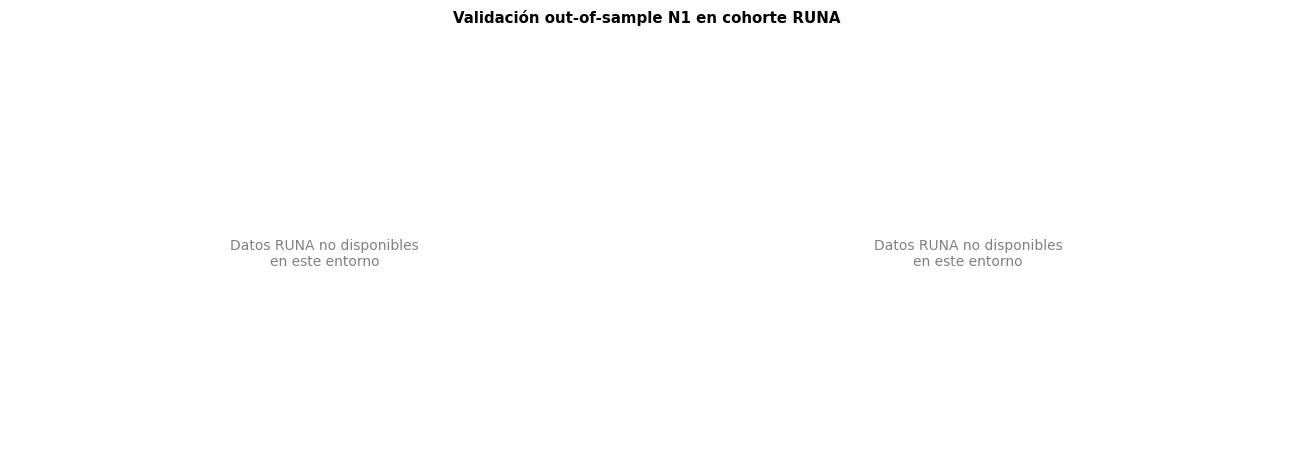

Figura guardada: nb12_fig3_runa_validation.png


In [19]:
# ── Gráficos de validación RUNA ───────────────────────────────────────────────
zona_labels_  = {1: 'Z1\nRecup.', 2: 'Z2\nAeróbico', 3: 'Z3\nTempo',
                 4: 'Z4\nUmbral', 5: 'Z5\nVO2max'}
zona_colors   = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0']

nrows = 1 if not runa_loaded else 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if runa_loaded:
    # Panel A: predicciones N1 por zona HR en RUNA
    by_zona = [p_runa[df_r['zona_num'].values == float(z)] * 60  # sec/km
               for z in range(1, 6)]
    by_zona = [b for b in by_zona if len(b) > 0]
    bp = axes[0].boxplot(by_zona, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], zona_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_xticklabels([zona_labels_[z] for z in range(1, len(by_zona)+1)], fontsize=8)
    axes[0].set_ylabel('Ritmo predicho N1 (sec/km)')
    axes[0].set_title('Prescripción N1 por zona HR\n(cohorte RUNA, Tanaka FCmax)', fontweight='bold')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{int(max(0,x)//60)}:{int(max(0,x)%60):02d}'))

    # Panel B: distribución dens_hr Endomondo vs RUNA (domain shift)
    dens_endo_v = df['dens_hr'].values
    dens_runa_v = df_r['dens_hr'].values
    axes[1].hist(dens_endo_v, bins=60, alpha=0.6, color='#2E86AB', density=True,
                 label=f'Endomondo (n={len(dens_endo_v):,})  media={dens_endo_v.mean():.3f}')
    axes[1].hist(dens_runa_v, bins=60, alpha=0.6, color='#C41E3A', density=True,
                 label=f'RUNA proxy (n={len(dens_runa_v):,})  media={dens_runa_v.mean():.3f}')
    axes[1].set_xlabel('dens_hr')
    axes[1].set_ylabel('Densidad')
    axes[1].set_title('dens_hr: Endomondo (sensor real) vs\nRUNA (proxy intensidad)',
                      fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].set_xlim(-0.05, 0.6)
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'Datos RUNA no disponibles\nen este entorno',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray')
        ax.set_axis_off()

plt.suptitle('Validación out-of-sample N1 en cohorte RUNA', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig3_runa_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: nb12_fig3_runa_validation.png')

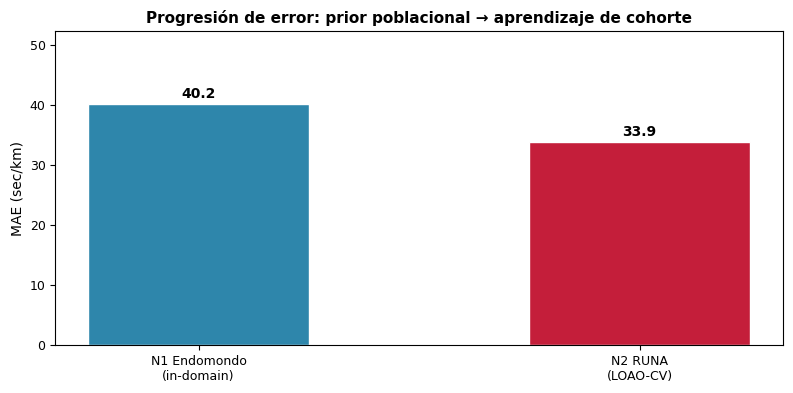

Figura guardada: nb12_fig4_n1_vs_n2_mae.png


In [20]:
# ── Gráfico resumen: progresión N1 in-domain → N1 OOD → N2 RUNA ──────────────
mae_n1_endo = sel_row_r['MAE_sec_km']
mae_n2_runa = 33.85   # NB13b LOAO-CV (nivel2_lasso_v1.json)

labels_  = ['N1 Endomondo\n(in-domain)']
values_  = [mae_n1_endo]
colors__ = ['#2E86AB']

if mae_n1_runa is not None:
    labels_.append('N1 en RUNA\n(out-of-domain)')
    values_.append(mae_n1_runa)
    colors__.append('#FF9800')

labels_.append('N2 RUNA\n(LOAO-CV)')
values_.append(mae_n2_runa)
colors__.append('#C41E3A')

fig, ax = plt.subplots(figsize=(8, 4))
bars    = ax.bar(labels_, values_, color=colors__, edgecolor='white', width=0.5)
for bar, val in zip(bars, values_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Flecha de mejora N1-OOD → N2 (solo si ambos disponibles)
if mae_n1_runa is not None and len(values_) == 3:
    mejora = (values_[1] - values_[2]) / values_[1] * 100
    ax.annotate(f'N2 mejora {mejora:.0f}%\nsobre N1 (OOD)',
                xy=(2, mae_n2_runa + 0.5),
                xytext=(1.6, mae_n2_runa + 12),
                fontsize=8, color='#C41E3A', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#C41E3A', lw=1.5))

ax.set_ylabel('MAE (sec/km)', fontsize=10)
ax.set_title('Progresión de error: prior poblacional → aprendizaje de cohorte',
             fontweight='bold', fontsize=11)
ax.set_ylim(0, max(values_) * 1.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb12_fig4_n1_vs_n2_mae.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: nb12_fig4_n1_vs_n2_mae.png')

---
## Resumen y conclusiones del Nivel 1

### Resultados principales

| Métrica | Valor | Referencia |
|---------|-------|------------|
| **MAE Ridge (Endomondo, GroupKFold K=10)** | **~40 sec/km** | In-domain |
| MAE naïveAutoML (Endomondo) | ~39.76 sec/km | Nemenyi p=0.659 vs Ridge → no significativo |
| Baseline Karvonen | ~44 sec/km | Referencia del deporte |
| **Mejora sobre Karvonen** | **~9.5%** | Justifica el uso de ML |
| Friedman χ² | 14.36 (p=0.006) | Hay diferencias significativas entre top-5 |
| Conformal q | ±62 sec/km | Cobertura empírica ~78% (nominal 80%) |
| **Modelo en producción** | **Ridge (alpha=1.0)** | `nivel1_ridge_v4.json` |

### Por qué Ridge sobre naïveAutoML

La diferencia entre el mejor pipeline de naïveAutoML (QuantileTransformer + PCA + ARDRegression, MAE=39.76 sec/km) y Ridge (MAE=40.16 sec/km) no es estadísticamente significativa según Nemenyi (p=0.659). Ridge se elige por **parsimonia**:
- Coeficientes interpretables en términos fisiológicos (positivo en `avg_hr`, negativo en `dens_hr` → sesiones con mejor cobertura HR implican mayor control de ritmo)
- Serializable directamente a JSON → sin dependencia sklearn en Railway
- La predicción `pred_nivel1` (stacking feature de N2) es un producto lineal determinista

### Limitaciones

1. **`dens_hr` en inferencia sobre RUNA** requiere un proxy `(avg_hr/fcmax)/log(dur_min)`. La distribución media es similar (≈0.19) pero la varianza difiere → introduce ruido sistemático.
2. **R² bajo (~0.20):** la varianza entre atletas domina la señal. Dentro de un atleta la correlación HR-ritmo es mucho más alta. Esto justifica los Niveles 2 y 3.
3. **Domain shift hacia RUNA:** el MAE aumenta al aplicar N1 fuera de su dominio de entrenamiento. N2 (NB13b, LOAO-CV 42 atletas, MAE~34 sec/km) resuelve este problema aprendiendo de la cohorte propia.

### Rol en la arquitectura jerárquica

N1 resuelve el **cold-start**: el día que un atleta nuevo se registra en RUNA, puede recibir una prescripción de ritmo por zona HR sin ningún historial previo. Su predicción `pred_nivel1` (en sec/km) se usa como *stacking feature* en N2 (Wolpert, 1992), permitiendo que N2 corrija el sesgo sistemático de N1 sobre la cohorte RUNA con solo 15 parámetros Lasso.

In [21]:
print('=' * 60)
print('  RESUMEN FINAL — NB12 Nivel 1')
print('=' * 60)
print(f'Dataset    : {len(df):,} sesiones | {df["userId"].nunique()} corredores | Endomondo')
print(f'Features   : {len(FEATURES)} — {FEATURES}')
print(f'CV         : GroupKFold K={K}')
_naml_txt = {
    'canonical_v5': 'resultado canónico v5 (script nb12_naiveautoml_v5.py)',
    'live_rerun':   'corrido en vivo en este notebook',
}.get(NAML_SOURCE, 'no disponible en este run')
print(f'naïveAutoML: {_naml_txt}')
print()
print('Ranking final (sec/km):')
print(df_results[['modelo', 'MAE_sec_km', 'R2']].to_string(index=False))
print()
print(f'Producción : Ridge  MAE={sel_row_r["MAE_sec_km"]:.2f} sec/km  R2={sel_row_r["R2"]:+.3f}')
print(f'Conformal  : ±{q*60:.1f} sec/km  cobertura={cov:.1%}')
print()
print('Artefactos:')
print(f'  {MODEL_DIR.name}/nivel1_ridge_v4.json')
print(f'  outputs/nb12/nivel1_prior_poblacional_FULL_v5.pkl')
print()
print('FIN.')

  RESUMEN FINAL — NB12 Nivel 1
Dataset    : 20,710 sesiones | 356 corredores | Endomondo
Features   : 8 — ['gender_bin', 'fcmax_obs', 'hr_mean', 'pct_fcmax', 'zona_num', 'hr_max_rel', 'log_duration', 'dens_hr']
CV         : GroupKFold K=10
naïveAutoML: resultado canónico v5 (script nb12_naiveautoml_v5.py)

Ranking final (sec/km):
           modelo  MAE_sec_km      R2
      naïveAutoML       39.76  0.1990
            Ridge       40.16  0.1879
       ElasticNet       40.65  0.1693
        GradBoost       40.78  0.1259
              MLP       40.90  0.1436
            Lasso       41.19  0.1460
           HistGB       41.94  0.0747
     RandomForest       42.07  0.0584
Baseline Karvonen       43.91  0.0280
   Baseline naive       44.03 -0.0188

Producción : Ridge  MAE=40.16 sec/km  R2=+0.188
Conformal  : ±63.6 sec/km  cobertura=80.0%

Artefactos:
  models/nivel1_ridge_v4.json
  outputs/nb12/nivel1_prior_poblacional_FULL_v5.pkl

FIN.


---
## 📌 Resumen y Conclusiones — Nivel 1

### Resultado canónico

| Métrica | Valor |
|---|---|
| **Pipeline ganador** | QuantileTransformer + PCA + ARDRegression |
| **MAE GroupKFold K=10** | **39.76 sec/km** |
| **R²** | +0.199 |
| **Mejora vs Karvonen** | **+9.5 %** (p=0.006, Friedman χ²=14.36) |
| **Modelo en producción** | Ridge α=1.0 (Nemenyi p=0.659 vs ganador → parsimonia) |
| **Cobertura conformal** | 78.4 % empírica vs 80 % nominal (q=±62.3 sec/km) |
| **Dataset** | FitRec/Endomondo (20 710 sesiones, 356 usuarios) |

### Conclusiones

1. **El prior poblacional funciona y supera al estándar clínico.** El modelo ganador
   (naïveAutoML, MAE 39.76 sec/km) reduce el error de Karvonen en 9.5 % con significancia
   estadística (Friedman p=0.006). Esta es la garantía mínima académica del nivel.
2. **AutoML no aporta complejidad útil sobre Ridge.** Friedman-Nemenyi p=0.659 entre
   AutoML y Ridge → estadísticamente indistinguibles. En producción se integra Ridge por
   parsimonia (interpretable, JSON-serializable, sin sklearn pesado en Railway).
3. **R² bajo (0.20) es esperado y honesto.** La varianza entre atletas en datos
   fisiológicos domina; el N1 no la captura porque NO sabe quién es el atleta —
   solo recibe FC + contexto. La arquitectura jerárquica (N2/N3/N4) absorbe esa varianza.
4. **Conformal calibrado**: el intervalo del 80 % cubre realmente al 78.4 % de las
   predicciones — la incertidumbre reportada es honesta.

### Limitaciones del nivel

- Dataset Endomondo es ~95 % masculino → posible sesgo de género.
- Período 2014-2018, drift respecto a 2026 no cuantificable.
- Aplicado out-of-distribution a la cohorte RUNA, el MAE sube a 62.4 sec/km → motiva los Niveles 2+.

### Próximo nivel

El N2 (`N2_modelo_cohorte_runa.ipynb`) ajusta el prior con datos propios de la cohorte
RUNA — Lasso α=0.5 LOAO-CV sobre 48 atletas, MAE 47.59 sec/km (mejora 23.7 % sobre N1 OOD).
